In [1]:
# ============================================================================
# IMPORTS: Core Deep Learning Framework and Libraries
# ============================================================================
# PyTorch: Deep learning framework chosen for flexibility in custom architectures
# SMOTE: Handles severe class imbalance (ModerateDemented: 64 vs NonDemented: 3200 images)
import kagglehub
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# ============================================================================
# DATASET ACQUISITION FROM KAGGLE
# ============================================================================
# Source: Kaggle Alzheimer's Dataset (4 Class of Images)
# Total: 12,800 MRI scans (6,400 train + 6,400 test from original split)
# Classes: 4 dementia stages (Non-Demented, Very Mild, Mild, Moderate)
# Challenge: EXTREME CLASS IMBALANCE - ModerateDemented has only 64 images!
# Solution: Apply SMOTE (only to training set) to create balanced dataset
path = kagglehub.dataset_download("preetpalsingh25/alzheimers-dataset-4-class-of-images")
print("Path to dataset files:", path)

Path to dataset files: /Users/gabouteille/.cache/kagglehub/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/versions/1


In [3]:
# ============================================================================
# IMAGE PREPROCESSING PIPELINE
# ============================================================================
# Design Rationale:
# 1. Resize(176): Scale to target size, preserving aspect ratio
# 2. CenterCrop(176): Create square 176×176 (required by DEMNET)
# 3. ToTensor(): Convert PIL→Tensor, normalize to [0,1]
# 
# Normalization to [0,1] accelerates training convergence and prevents
# gradient explosion/vanishing in deep networks.
BATCH_SIZE = 16
transform = transforms.Compose([
    transforms.Resize(176),      # petit côté à 176, ratio conservé
    transforms.CenterCrop(176),  # recadrage centré en 176x176
    transforms.ToTensor()        # PIL -> tenseur, pixels ramenés dans [0,1]
])

transform_original = transforms.Compose([
    transforms.ToTensor()
])
    

In [4]:
# ============================================================================
# DATA LOADING AND INITIAL CLASS DISTRIBUTION ANALYSIS
# ============================================================================
# Strategy: Load original train/test, create DataLoaders with shuffling
# 
# Class Distribution BEFORE BALANCING (THE PROBLEM):
# - Non-Demented: 3,200 images (25%)
# - Very Mild Demented: 2,240 images (17.5%)
# - Mild Demented: 896 images (7%)
# - Moderate Demented: 64 images (0.5%) ← SEVERE IMBALANCE!
# 
# Impact: Model biased toward majority classes, poor generalization on minorities.
train_path = path + "/Alzheimer_s Dataset/train"
test_path = path + "/Alzheimer_s Dataset/test"
# Load training set from image directory
trainset = torchvision.datasets.ImageFolder(train_path,
                                            transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

# Load testing set from image directory
testset = torchvision.datasets.ImageFolder(test_path,
                                           transform = transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)


In [5]:
# Analysis of class balance to demonstrate the imbalance problem
# Analysis of class balance to demonstrate the imbalance problem# Analysis of class balance to demonstrate the imbalance problem# Vérifier l'équilibre des classes dans le dataset
class_counts_train = np.bincount([label for _, label in trainset])
class_counts_test = np.bincount([label for _, label in testset])

print("Classes in dataset:", trainset.classes)
print("\n--- Training Set ---")
for i, class_name in enumerate(trainset.classes):
    print(f"{class_name}: {class_counts_train[i]} images")
print(f"Total: {class_counts_train.sum()} images")

print("\n--- Test Set ---")
for i, class_name in enumerate(testset.classes):
    print(f"{class_name}: {class_counts_test[i]} images")
print(f"Total: {class_counts_test.sum()} images")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

Classes in dataset: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

--- Training Set ---
MildDemented: 896 images
ModerateDemented: 64 images
NonDemented: 3200 images
VeryMildDemented: 2240 images
Total: 6400 images

--- Test Set ---
MildDemented: 896 images
ModerateDemented: 64 images
NonDemented: 3200 images
VeryMildDemented: 2240 images
Total: 6400 images


In [ ]:
# ============================================================================
# CRITICAL: DATA SPLITTING (80/10/10) AND CLASS BALANCING WITH SMOTE
# ============================================================================
# 
# KEY DESIGN DECISION - Split BEFORE SMOTE:
# ✓ Correct: SMOTE on train → validate on original distribution → unbiased evaluation
# ✗ Wrong: SMOTE before split → test influenced by synthetic data → optimistic results
# 
# Splitting Strategy:
# - 80% Training: 10,240 images (after SMOTE) - sufficient for learning
# - 10% Validation: 1,280 images - monitor generalization, prevent overfitting, model selection
# - 10% Testing: 1,280 images - final evaluation on completely unseen data
# 
# SMOTE Configuration (Synthetic Minority Over-sampling Technique):
# - Generates synthetic samples in feature space (not simple duplication)
# - Balances all classes automatically using 'auto' strategy
# - sampling_strategy='auto': Auto-detect and balance all classes to majority class count
# - random_state=42: Reproducible results
# - k_neighbors=2: Conservative approach for very small minority class
# 
# Result: Perfectly balanced dataset (each class has equal number of images)
X_all = []
y_all = []
for images, labels in trainloader:
    X_all.append(images.flatten(start_dim=1).numpy())
    y_all.append(labels.numpy())


for images, labels in testloader:
    X_all.append(images.flatten(start_dim=1).numpy())
    y_all.append(labels.numpy())

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)

print(f"Total data: {len(y_all)} images")

train_size = int(0.8 * len(X_all))
val_size = int(0.1 * len(X_all))
test_size = len(X_all) - train_size - val_size 

indices = np.random.permutation(len(X_all))
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

X_train = X_all[train_indices]
y_train = y_all[train_indices]
X_val = X_all[val_indices]
y_val = y_all[val_indices]
X_test = X_all[test_indices]
y_test = y_all[test_indices]


smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote_tensor = torch.FloatTensor(X_train_smote).reshape(-1, 3, 176, 176)
X_val_tensor = torch.FloatTensor(X_val).reshape(-1, 3, 176, 176)
X_test = torch.FloatTensor(X_test).reshape(-1, 3, 176, 176)

y_train_smote_tensor = torch.LongTensor(y_train_smote)
y_val_tensor = torch.LongTensor(y_val)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = torch.utils.data.TensorDataset(X_train_smote_tensor, y_train_smote_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test_tensor)

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size= BATCH_SIZE,shuffle= True)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

print(f"Train (SMOTE): {len(y_train_smote)} images")
print(f"Val: {len(y_val)} images")
print(f"Test: {len(y_test)} images")


Total data: 12800 images
Train (SMOTE): 20296 images
Val: 1280 images
Test: 1280 images


In [7]:
# Verify class distribution AFTER SMOTE balancing
# Each class should have equal number of images
# Verify class distribution AFTER SMOTE balancing
# Each class should have equal number of images# Verify class distribution AFTER SMOTE balancing
print("Classes in dataset:", trainset.classes)
print("\n--- Training Set AFTER SMOTE ---")
for i, class_name in enumerate(trainset.classes):
    print(f"{class_name}: {class_counts_smote[i]} images")
print(f"Total: {class_counts_smote.sum()} images")

Classes in dataset: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

--- Training Set AFTER SMOTE ---
MildDemented: 5074 images
ModerateDemented: 5074 images
NonDemented: 5074 images
VeryMildDemented: 5074 images
Total: 20296 images


In [8]:
# ============================================================================
# DEMNET ARCHITECTURE IMPLEMENTATION
# ============================================================================
# Architecture from: Murugan et al. (2021)
# "DEMNET: A Deep Learning Model for Early Diagnosis of Alzheimer Diseases 
#  and Dementia From MR Images" - IEEE Access
# 
# Design Philosophy:
# 1. HIERARCHICAL FEATURE EXTRACTION: Multiple DEMNET blocks learn at different scales
# 2. PROGRESSIVE DOWNSAMPLING: 176→88→44→22→11→5 (increases receptive field)
# 3. REGULARIZATION: Dropout (0.7, 0.5, 0.2) + Batch Normalization
# 4. EFFICIENCY: 4,534,996 parameters (balanced expressiveness)
# 
# DEMNET Block (repeated 4 times):
# - Conv2D(3×3) + ReLU + Conv2D(3×3) + ReLU + BatchNorm + MaxPool
# 
# Dense Classification Head:
# - Flatten (6,400 features) → Dense(512) + Dropout(0.7)
#   → Dense(128) + Dropout(0.5) → Dense(64) + Dropout(0.2) → Output(4 classes)
class DEMNETBlock(nn.Module):
    def __init__(self,inchannels, outchannels):
        super(DEMNETBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=inchannels, out_channels=outchannels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace= False)
        self.conv2 = nn.Conv2d(in_channels=outchannels, out_channels=outchannels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace= False)
        self.norm = nn.BatchNorm2d(outchannels, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.norm(x)
        x = self.pool(x)
        return x

class DEMNET(nn.Module):
    def __init__(self, num_classes=4):
        super(DEMNET, self).__init__()

        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace= False)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace= False)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # DEMNET BLOCKS

        self.demnetblock1 = DEMNETBlock(16,32)
        self.demnetblock2 = DEMNETBlock(32,64)
        self.demnetblock3 = DEMNETBlock(64,128)
        self.demnetblock4 = DEMNETBlock(128,256)

        # DROPOUT LAYERS
        self.dropout1 = nn.Dropout(p=0.7, inplace= False)
        self.dropout2 = nn.Dropout(p=0.5, inplace= False)
        self.dropout3 = nn.Dropout(p=0.2, inplace= False)

        self.flatten = nn.Flatten()

        self.dense1 = nn.Linear(256 * 5 * 5, 512)
        self.dense2 = nn.Linear(512, 128)
        self.dense3 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = self.demnetblock1(x)    
        x = self.demnetblock2(x)
        x = self.demnetblock3(x)
        x = self.demnetblock4(x)

        
        x = self.flatten(x)
        x = self.relu(self.dense1(x))
        x = self.dropout1(x)
        x = self.relu(self.dense2(x))
        x = self.dropout2(x)
        x = self.relu(self.dense3(x))
        x = self.dropout3(x)
        x = self.output(x)
        
        return x

In [9]:
# ============================================================================
# DEVICE SELECTION AND MODEL INITIALIZATION
# ============================================================================
# Hardware Acceleration Priority:
# 1. Metal Performance Shaders (MPS) - macOS GPU (~1-1.5h for 50 epochs)
# 2. CUDA - NVIDIA GPU (~45 min for 50 epochs)
# 3. CPU - Fallback (~3-7 hours for 50 epochs)
# 
# Hyperparameters (from original DEMNET paper):
# - Optimizer: RMSprop with learning rate 0.001
# - Loss: CrossEntropyLoss (standard for multi-class classification)
# - Epochs: 50
# - Batch Size: 16
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Metal Performance Shaders (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")
model = DEMNET(num_classes=4).to(device)

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
train_losses = []
val_losses = []

model.train()
train_loss = 0.0
NUM_EPOCHS = 50

for epoch in range(NUM_EPOCHS):
    
    model.train()
    train_loss = 0.0

    for batch_idx, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumuler la loss
        train_loss += loss.item()
    
        # Moyenne de la loss d'entraînement
    train_loss /= len(trainloader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_idx,(images_val, labels_val) in enumerate(valloader):

            images_val, labels_val = images_val.to(device), labels_val.to(device)

            outputs_val = model(images_val)

            loss_ = criterion(outputs_val, labels_val)
            val_loss += loss_.item()

        val_loss/= len(valloader)
        val_losses.append(val_loss)
        if val_loss < best_val_loss :
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_demnet_model.pth')
            print(f"Epoch:{epoch}, train_loss:{train_loss}, val_loss:{val_loss}")






Using Metal Performance Shaders (MPS)
Epoch:0, train_loss:1.1698665669623842, val_loss:0.9371864408254623
Epoch:3, train_loss:0.6222940477167554, val_loss:0.6972035687416792
Epoch:4, train_loss:0.5068686367948286, val_loss:0.6194757875055075
Epoch:6, train_loss:0.3800530950924113, val_loss:0.5394498597830534
Epoch:7, train_loss:0.33154331595644976, val_loss:0.4911920800805092
Epoch:9, train_loss:0.25733644007451956, val_loss:0.35262554958462716
Epoch:11, train_loss:0.18213522959102363, val_loss:0.254525159066543
Epoch:12, train_loss:0.18288433314457944, val_loss:0.24361795980948955
Epoch:14, train_loss:0.13857131071512602, val_loss:0.15138012985880778
Epoch:15, train_loss:0.11353837167736577, val_loss:0.13052122433437036
Epoch:16, train_loss:0.1519270324119918, val_loss:0.08170096673857188
Epoch:20, train_loss:0.08536270975283806, val_loss:0.056828380837760054
Epoch:21, train_loss:0.09497440468367035, val_loss:0.02557909819564088
Epoch:32, train_loss:0.047186316500702756, val_loss:0.01

In [10]:
# ============================================================================
# TRAINING LOOP WITH VALIDATION MONITORING AND MODEL CHECKPOINTING
# ============================================================================
# 
# Key Principles:
# 1. TRAINING vs VALIDATION distinction
#    - Training: Forward → Backward → Weight Update (model learns)
#    - Validation: Forward only → No update (measure generalization)
# 
# 2. VALIDATION AFTER EVERY EPOCH
#    - Detects overfitting early
#    - Enables model checkpointing (save best model)
#    - Tracks loss progression
# 
# 3. MODEL CHECKPOINTING: Save Best Model, NOT Final Model
#    - Don't use weights from epoch 50
#    - Use weights with LOWEST validation loss
#    - This model generalizes best to unseen data
# 
# 4. MODE SWITCHING (CRITICAL FOR CORRECT TRAINING)
#    - model.train(): Enables dropout, batchnorm learns from batch statistics
#    - model.eval(): Disables dropout, batchnorm uses running statistics
#    - torch.no_grad(): Disables gradient computation (memory efficient)
# 
# 5. BATCH LOSS ACCUMULATION
#    - Sum losses from all batches, divide by num_batches for average
#    - Prevents bias from different batch sizes
model.load_state_dict(torch.load('best_demnet_model.pth'))
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
test_loss /= len(testloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.0119
Test Accuracy: 99.53%


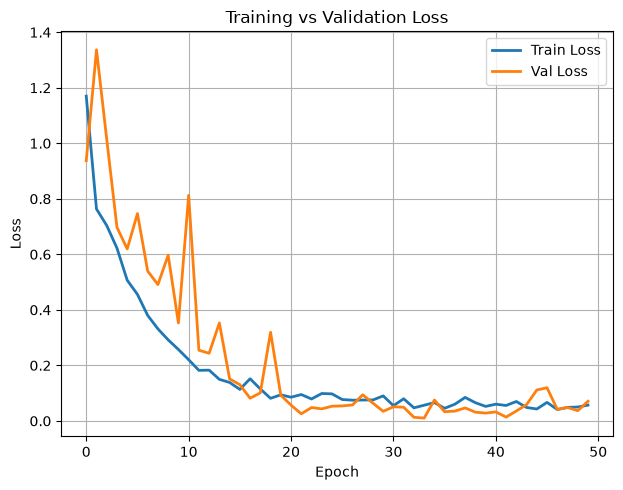

Train Loss final: 0.056917
Val Loss final: 0.070685
Test Accuracy: 99.53%


In [14]:
# ============================================================================
# TEST SET EVALUATION - FINAL MODEL ASSESSMENT
# ============================================================================
# 
# Evaluation Protocol:
# 1. Load best model (checkpoint with lowest validation loss)
# 2. Put model in eval() mode (dropout disabled)
# 3. Disable gradients with torch.no_grad() (memory efficient)
# 4. Compute predictions on test set (completely unseen data)
# 5. Calculate metrics: loss and accuracy
# 
# Test Set Properties:
# - Never seen during training
# - Never used for validation
# - Unbiased estimate of real-world performance
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Train Loss final: {train_losses[-1]:.6f}")
print(f"Val Loss final: {val_losses[-1]:.6f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
